#Install Library

In [26]:
!pip install pmdarima

#Import Library

In [27]:
# Data manipulation
import pandas as pd
import numpy as np
import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from matplotlib.ticker import FuncFormatter

# Time Series
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Auto ARIMA
from pmdarima import auto_arima

# Prophet
from prophet import Prophet
from prophet.plot import plot_plotly

# Evaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

# Warning
import warnings
warnings.filterwarnings("ignore")

# Optional
nlag = 40

#Read Data

In [28]:
df = pd.read_csv('https://raw.github.com/nadiraaini77/Dataset/main/jisdor_kurs.csv')

In [29]:
df

,tanggal,kurs
0,2022-02-16,14278
1,2022-02-17,14301
2,2022-02-18,14339
3,2022-02-21,14329
4,2022-02-22,14362
...,...,...
1048,2026-07-10,18069
1049,2026-07-13,18131
1050,2026-07-14,18099
1051,2026-07-15,18064


#Data Understanding

In [30]:
df.shape

(1053, 2)

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1053 entries, 0 to 1052
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   tanggal  1053 non-null   object
 1   kurs     1053 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 16.6+ KB


In [32]:
df.isnull().sum()

,0
tanggal,0
kurs,0


In [33]:
df.duplicated().sum()

np.int64(0)

In [34]:
df.describe()

,kurs
count,1053.000000
mean,15842.018044
std,838.648493
min,14278.000000
25%,15197.000000
50%,15713.000000
75%,16391.000000
max,18171.000000


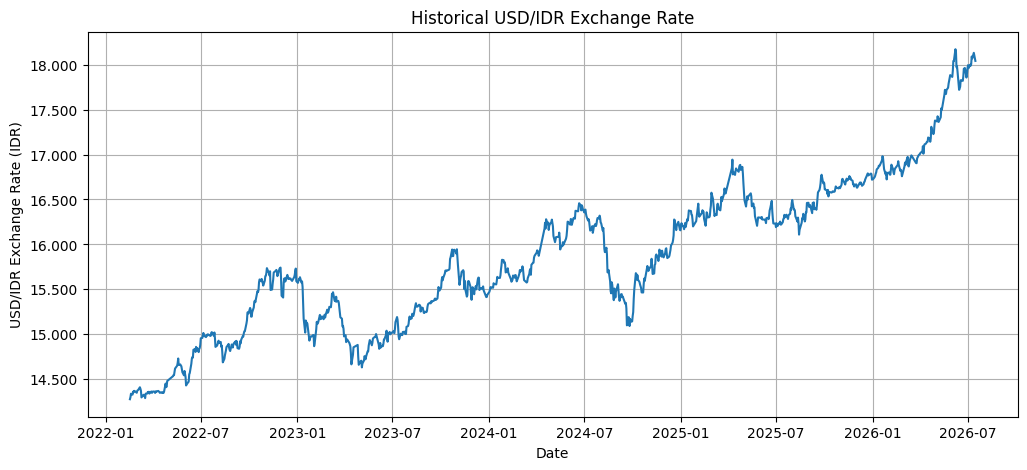

In [35]:
df['tanggal'] = pd.to_datetime(df['tanggal'])
plt.figure(figsize=(12,5))
plt.plot(df["tanggal"], df["kurs"])
plt.title("Historical USD/IDR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD/IDR Exchange Rate (IDR)")
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)
plt.show()

#Data Preprocessing

##Parsing Date Format

In [36]:
df["tanggal"] = pd.to_datetime(df["tanggal"])

##Sorting (Berdasarkan Waktu)

In [37]:
df = df.sort_values("tanggal")

##Duplicate Handling

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
# df.reset_index().duplicated().sum()

##Set Index

In [40]:
df = df.set_index("tanggal")

##Resampling

In [41]:
df = df.asfreq("B")

##Missing value handling  

In [42]:
df.isnull().sum()

,0
kurs,99


In [43]:
df["kurs"] = (
    df["kurs"]
    .ffill()
)

In [44]:
# cek ulang
df.isnull().sum()

,0
kurs,0


#EDA

##Time Series Plot

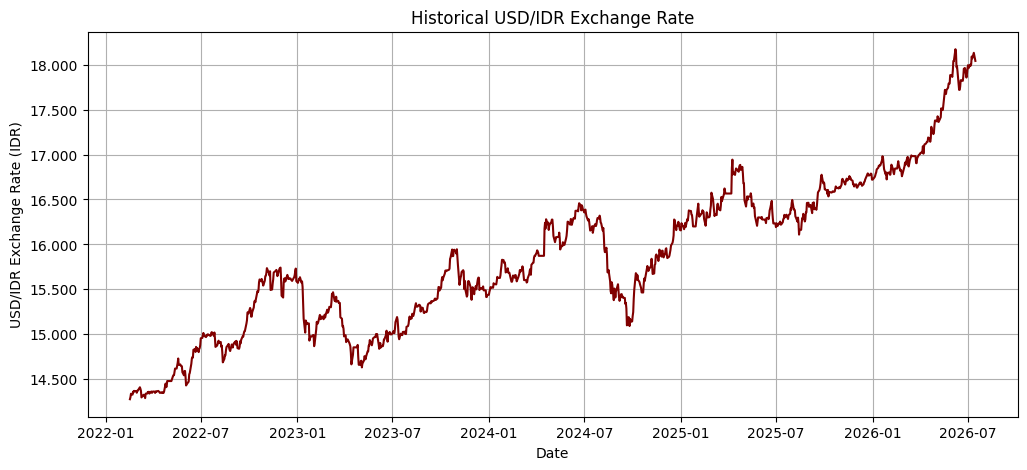

In [45]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))

plt.plot(
    df.index,
    df["kurs"],
    color="maroon"
)

plt.title("Historical USD/IDR Exchange Rate")
plt.xlabel("Date")
plt.ylabel("USD/IDR Exchange Rate (IDR)")
plt.grid(True)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##Distribution

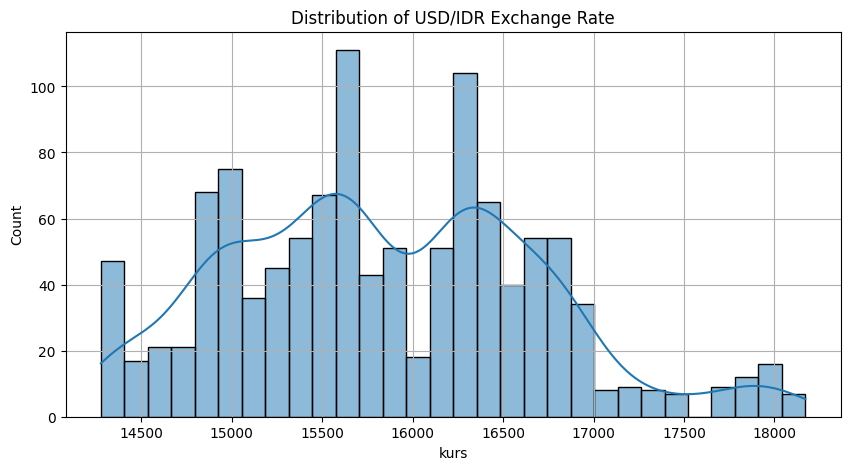

In [46]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["kurs"],
    bins=30,
    kde=True
)

plt.grid(True)
plt.title("Distribution of USD/IDR Exchange Rate")
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##Rolling Mean & Standard Deviation

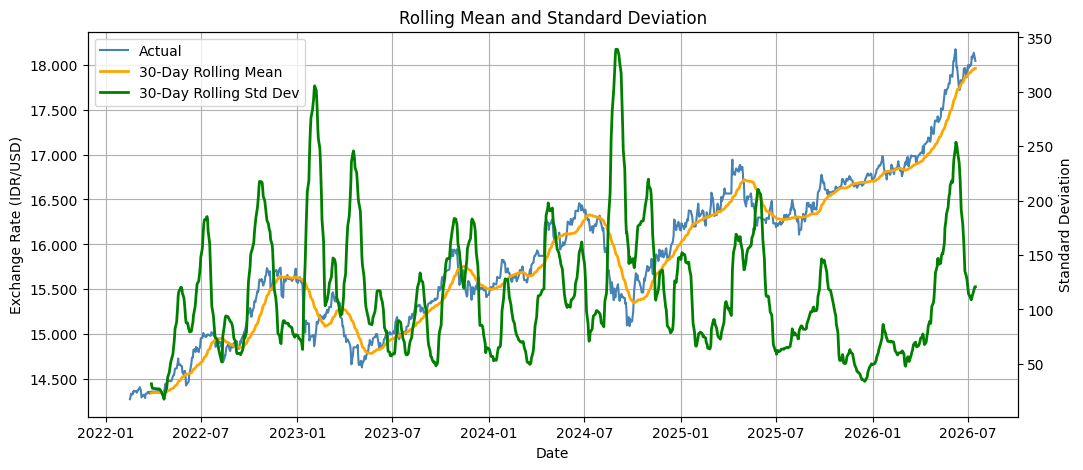

In [48]:
rolling_mean = df["kurs"].rolling(window=30).mean()
rolling_std = df["kurs"].rolling(window=30).std()

fig, ax1 = plt.subplots(figsize=(12,5))

# Actual & Rolling Mean
ax1.plot(df.index, df["kurs"], label="Actual", color="steelblue")
ax1.plot(df.index, rolling_mean, label="30-Day Rolling Mean", color="orange", linewidth=2)

ax1.set_xlabel("Date")
ax1.set_ylabel("Exchange Rate (IDR/USD)")
ax1.grid(True)

ax1.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

# Rolling Std Dev
ax2 = ax1.twinx()

ax2.plot(df.index, rolling_std,
         label="30-Day Rolling Std Dev",
         color="green",
         linewidth=2)

ax2.set_ylabel("Standard Deviation")

plt.title("Rolling Mean and Standard Deviation")

# Gabungkan legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.show()

Grafik menunjukkan bahwa rolling mean mengalami tren meningkat seiring waktu, sedangkan rolling standard deviation berfluktuasi dan tidak konstan. Hal ini mengindikasikan bahwa data nilai tukar USD/IDR memiliki tren dan tingkat volatilitas yang berubah-ubah, sehingga data belum bersifat stasioner dan memerlukan proses transformasi sebelum dilakukan pemodelan time series.

##Moving Average

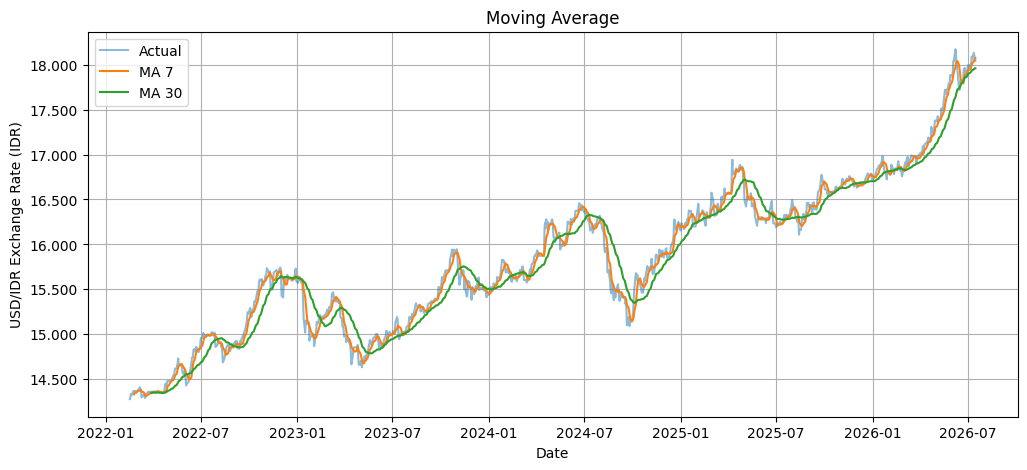

In [51]:
ma7 = df["kurs"].rolling(7).mean()

ma30 = df["kurs"].rolling(30).mean()

plt.figure(figsize=(12,5))

plt.plot(df.index,
         df["kurs"],
         alpha=0.5,
         label="Actual")

plt.plot(df.index,
         ma7,
         label="MA 7")

plt.plot(df.index,
         ma30,
         label="MA 30")

plt.legend()
plt.grid(True)
plt.title("Moving Average")
plt.xlabel("Date")
plt.ylabel("USD/IDR Exchange Rate (IDR)")

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)
plt.show()

##Trend & Seasonal Analysis

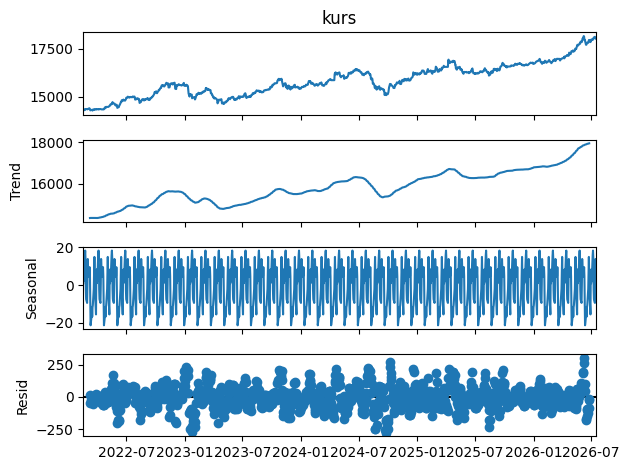

In [52]:
decomposition = seasonal_decompose(
    df["kurs"],
    model="additive",
    period=30
)

decomposition.plot()
plt.show()

Hasil dekomposisi menunjukkan adanya tren meningkat pada nilai tukar USD/IDR. Selain itu, terdapat pola musiman yang berulang, sedangkan komponen residual menunjukkan fluktuasi acak di sekitar nol yang tidak membentuk pola tertentu.

#Modeling

##Train Test Split

In [53]:
series = df["kurs"]

In [54]:
train_size = int(len(series) * 0.8)

train = series[:train_size]
test = series[train_size:]

print("Jumlah data train :", len(train))
print("Jumlah data test  :", len(test))

Jumlah data train : 921
Jumlah data test  : 231


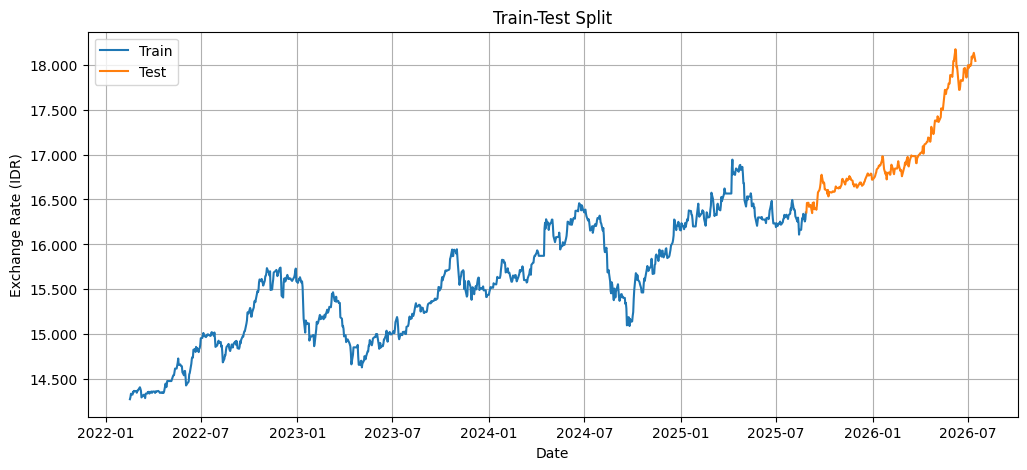

In [55]:
plt.figure(figsize=(12,5))

plt.plot(train.index,
         train,
         label="Train")

plt.plot(test.index,
         test,
         label="Test")

plt.title("Train-Test Split")
plt.ylabel('Exchange Rate (IDR)')
plt.xlabel('Date')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##ARIMA

In [56]:
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True)
print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=9932.590, Time=3.59 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=9950.895, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=9942.326, Time=0.17 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=9939.450, Time=0.61 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=9950.508, Time=0.11 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=9934.519, Time=1.53 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=9934.142, Time=1.65 sec
 ARIMA(3,1,2)(0,0,0)[0] intercept   : AIC=9933.961, Time=3.93 sec
 ARIMA(2,1,3)(0,0,0)[0] intercept   : AIC=9933.886, Time=5.39 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=9933.818, Time=0.55 sec
 ARIMA(1,1,3)(0,0,0)[0] intercept   : AIC=9934.006, Time=1.70 sec
 ARIMA(3,1,1)(0,0,0)[0] intercept   : AIC=9935.260, Time=1.15 sec
 ARIMA(3,1,3)(0,0,0)[0] intercept   : AIC=9929.209, Time=2.79 sec
 ARIMA(4,1,3)(0,0,0)[0] intercept   : AIC=9932.438, Time=5.11 sec
 ARIMA(3,1,4)(0,0,0)[0] intercept

In [57]:
arma_model = ARIMA(train,order=(3,1,3))
arma_fit = arma_model.fit()

In [58]:
arma_pred = arma_fit.forecast(steps=len(test))

In [59]:
arma_future = arma_fit.forecast(steps=30)

In [60]:
#cek apakah sudah datetimeindex
arma_future = arma_fit.forecast(steps=30)

print(arma_future.index)

DatetimeIndex(['2025-08-28', '2025-08-29', '2025-09-01', '2025-09-02',
               '2025-09-03', '2025-09-04', '2025-09-05', '2025-09-08',
               '2025-09-09', '2025-09-10', '2025-09-11', '2025-09-12',
               '2025-09-15', '2025-09-16', '2025-09-17', '2025-09-18',
               '2025-09-19', '2025-09-22', '2025-09-23', '2025-09-24',
               '2025-09-25', '2025-09-26', '2025-09-29', '2025-09-30',
               '2025-10-01', '2025-10-02', '2025-10-03', '2025-10-06',
               '2025-10-07', '2025-10-08'],
              dtype='datetime64[ns]', freq='B')


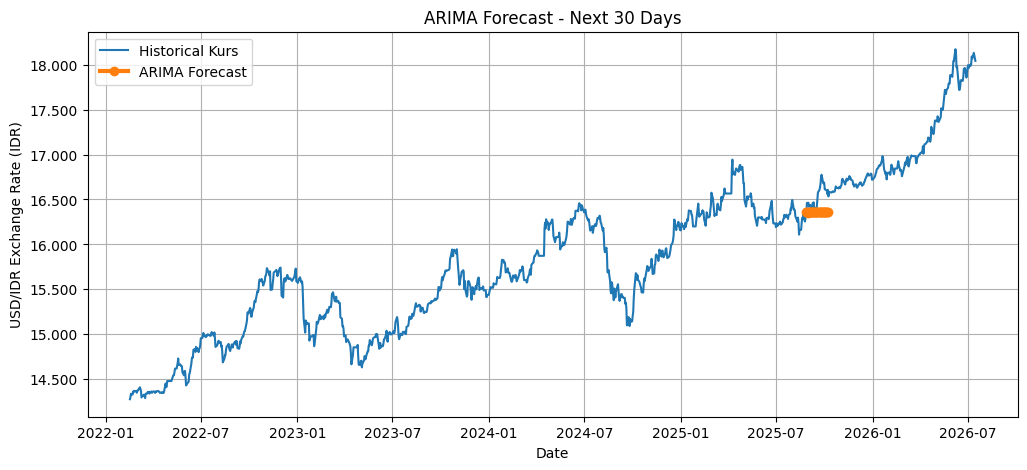

In [61]:
plt.figure(figsize=(12,5))

plt.plot(
    series.index,
    series.values,
    label='Historical Kurs'
)

plt.plot(
    arma_future.index,
    arma_future.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast'
)

plt.title('ARIMA Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

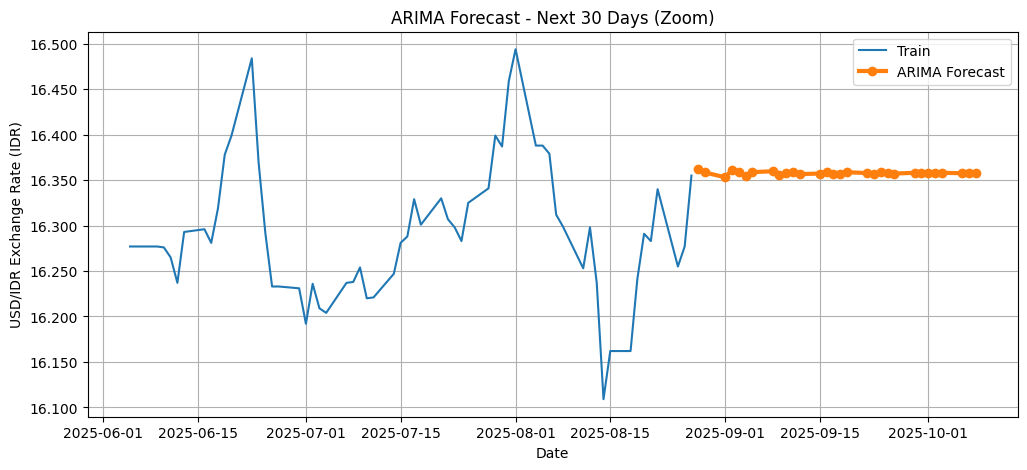

In [62]:
plt.figure(figsize=(12,5))

plt.plot(
    train.iloc[-60:].index,
    train.iloc[-60:].values,
    label='Train'
)

plt.plot(
    arma_future.index,
    arma_future.values,
    marker='o',
    linewidth=3,
    label='ARIMA Forecast'
)

plt.title('ARIMA Forecast - Next 30 Days (Zoom)')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##SARIMA

In [63]:
auto_arima(train,seasonal=True,m=5,trace=True)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[5] intercept   : AIC=9934.226, Time=3.83 sec
 ARIMA(0,1,0)(0,0,0)[5] intercept   : AIC=9950.895, Time=0.08 sec
 ARIMA(1,1,0)(1,0,0)[5] intercept   : AIC=9944.271, Time=0.25 sec
 ARIMA(0,1,1)(0,0,1)[5] intercept   : AIC=9941.358, Time=0.81 sec
 ARIMA(0,1,0)(0,0,0)[5]             : AIC=9950.508, Time=0.09 sec
 ARIMA(2,1,2)(0,0,1)[5] intercept   : AIC=9932.543, Time=5.62 sec
 ARIMA(2,1,2)(0,0,0)[5] intercept   : AIC=9932.590, Time=2.50 sec
 ARIMA(2,1,2)(0,0,2)[5] intercept   : AIC=9934.094, Time=5.20 sec
 ARIMA(2,1,2)(1,0,0)[5] intercept   : AIC=9932.621, Time=4.69 sec
 ARIMA(2,1,2)(1,0,2)[5] intercept   : AIC=9936.093, Time=5.72 sec
 ARIMA(1,1,2)(0,0,1)[5] intercept   : AIC=9936.296, Time=1.25 sec
 ARIMA(2,1,1)(0,0,1)[5] intercept   : AIC=9935.832, Time=1.75 sec
 ARIMA(3,1,2)(0,0,1)[5] intercept   : AIC=9933.651, Time=5.84 sec
 ARIMA(2,1,3)(0,0,1)[5] intercept   : AIC=9933.573, Time=3.99 sec
 ARIMA(1,1,1)(0,0,1)[5] intercept

ARIMA(order=(3, 1, 3), scoring_args={}, seasonal_order=(0, 0, 0, 5),
      suppress_warnings=True, with_intercept=False)

In [64]:
sarima_model = SARIMAX(train,
    order=(3,1,3),
    seasonal_order=(0,0,0,5))
sarima_fit = sarima_model.fit()

In [65]:
sarima_pred = sarima_fit.forecast(len(test))

In [66]:
sarima_future = sarima_fit.forecast(30)

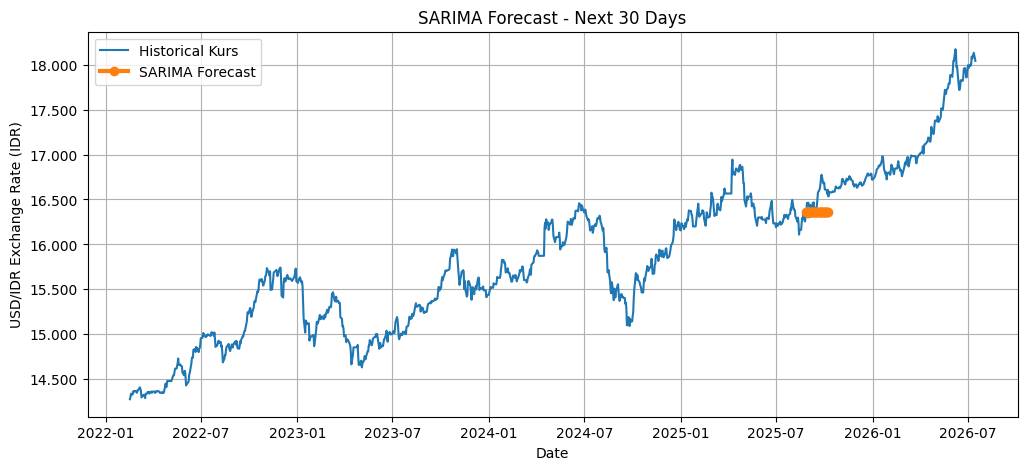

In [67]:
plt.figure(figsize=(12,5))
plt.plot(
    series.index,
    series.values,
    label='Historical Kurs')
plt.plot(
    sarima_future.index,
    sarima_future.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast')
plt.title('SARIMA Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

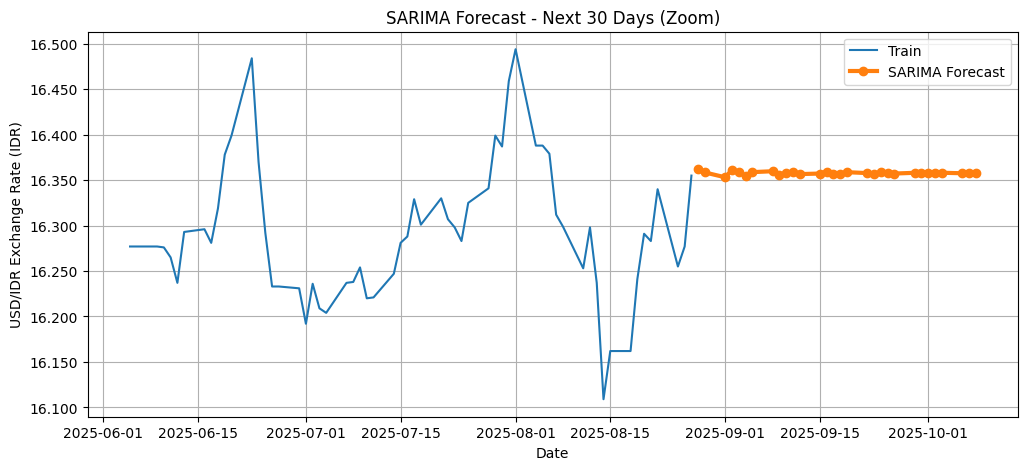

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    train.iloc[-60:].index,
    train.iloc[-60:].values,
    label='Train'
)

plt.plot(
    sarima_future.index,
    sarima_future.values,
    marker='o',
    linewidth=3,
    label='SARIMA Forecast'
)

plt.title('SARIMA Forecast - Next 30 Days (Zoom)')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##Holt-Winters

In [69]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=5)
hw_fit = hw_model.fit()
hw_pred = hw_fit.forecast(len(test))
hw_future = hw_fit.forecast(30)

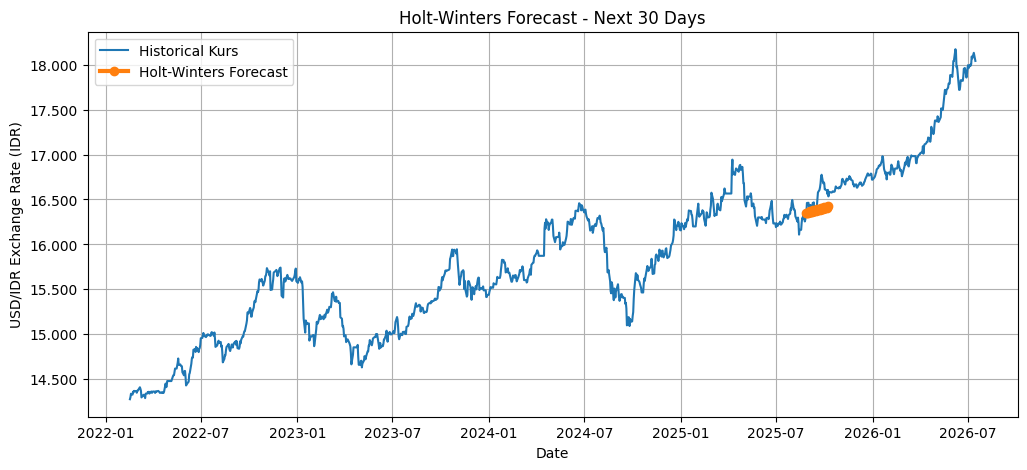

In [70]:
plt.figure(figsize=(12,5))

plt.plot(
    series.index,
    series.values,
    label='Historical Kurs'
)

plt.plot(
    hw_future.index,
    hw_future.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast'
)

plt.title('Holt-Winters Forecast - Next 30 Days')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

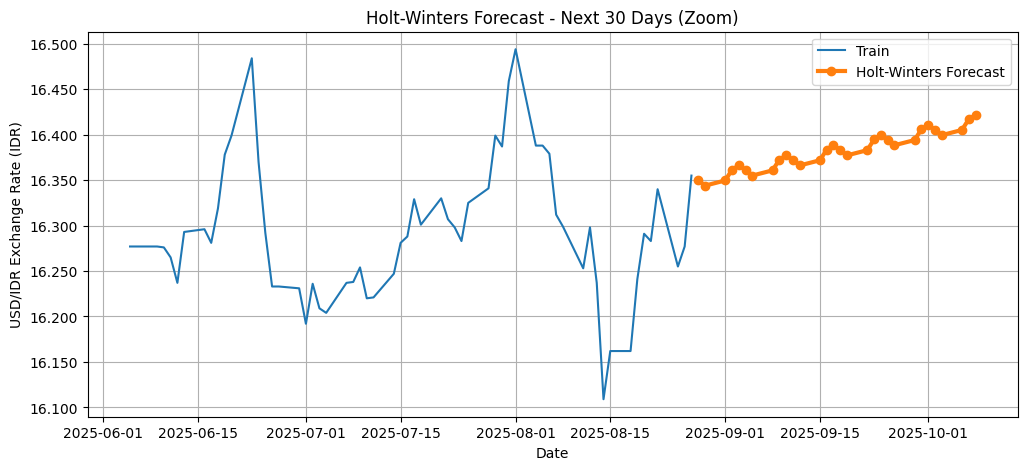

In [71]:
plt.figure(figsize=(12,5))

plt.plot(
    train.iloc[-60:].index,
    train.iloc[-60:].values,
    label='Train'
)

plt.plot(
    hw_future.index,
    hw_future.values,
    marker='o',
    linewidth=3,
    label='Holt-Winters Forecast'
)

plt.title('Holt-Winters Forecast - Next 30 Days (Zoom)')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)

plt.show()

##Prophet

In [72]:
prophet_train = train.reset_index()
prophet_train.columns = ['ds', 'y']
prophet_model = Prophet(seasonality_mode='additive',
    seasonality_prior_scale=15,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False)
prophet_model.fit(prophet_train)

In [73]:
future_test = prophet_model.make_future_dataframe(
    periods=len(test),freq='B')
forecast_test = prophet_model.predict(future_test)
prophet_pred = forecast_test[['ds','yhat']].tail(len(test))
prophet_pred = pd.Series(prophet_pred['yhat'].values,index=test.index)

In [74]:
prophet_full = series.reset_index()
prophet_full.columns = ['ds', 'y']
prophet_final = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=15,
    yearly_seasonality=True)
prophet_final.fit(prophet_full)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [75]:
future_30 = prophet_final.make_future_dataframe(
    periods=30,freq='B')
forecast_30 = prophet_final.predict(future_30)
prophet_future = (forecast_30[['ds','yhat']].tail(30).set_index('ds'))

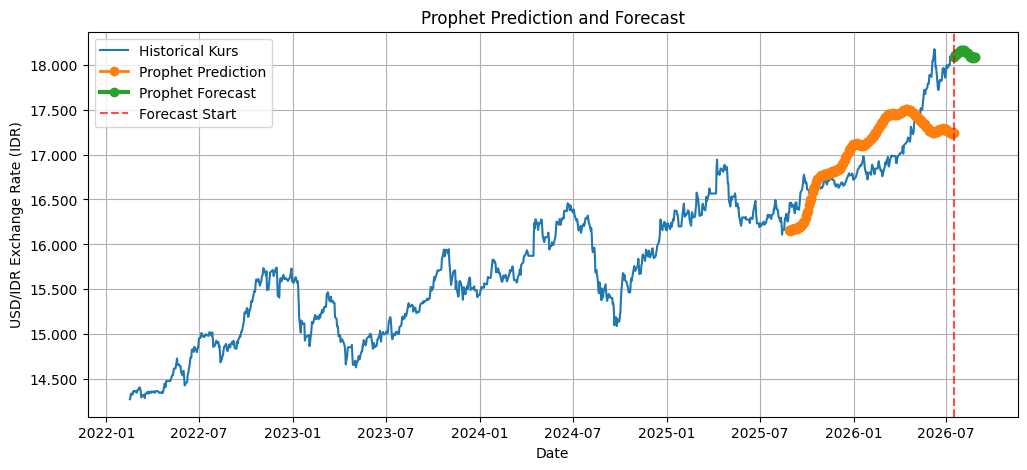

In [76]:
plt.figure(figsize=(12,5))
plt.plot(
    series.index,
    series.values,
    label='Historical Kurs')

plt.plot(
    prophet_pred.index,
    prophet_pred.values,
    marker='o',
    linewidth=2,
    label='Prophet Prediction')

plt.plot(
    prophet_future.index,
    prophet_future['yhat'],
    marker='o',
    linewidth=3,
    label='Prophet Forecast')

plt.axvline(
    series.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start')

plt.title('Prophet Prediction and Forecast')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}'.replace(',', '.'))
)
plt.grid(True)
plt.show()

In [77]:
# cek letak garis merah udh bnr blm
print(series.index[-1])
print(prophet_future.index[0])

2026-07-16 00:00:00
2026-07-17 00:00:00


#Model Evaluation

In [78]:
import numpy as np
def evaluate(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    mape = mean_absolute_percentage_error(
        y_true,
        y_pred
    ) * 100

    return mae, rmse, mape
results = []

results.append(
    ["ARIMA", *evaluate(test, arma_pred)]
)

results.append(
    ["SARIMA", *evaluate(test, sarima_pred)]
)

results.append(
    ["Holt-Winters", *evaluate(test, hw_pred)]
)

results.append(
    ["Prophet", *evaluate(test, prophet_pred)]
)

results = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)

results

,Model,MAE,RMSE,MAPE
0,ARIMA,668.011517,826.728231,3.846901
1,SARIMA,668.011517,826.728231,3.846901
2,Holt-Winters,420.483876,551.774956,2.414204
3,Prophet,345.912433,404.856093,2.011069


In [79]:
print(auto_model.order)
print(auto_model.seasonal_order)

(3, 1, 3)
(0, 0, 0, 0)


In [ ]:
auto_model_sarima = auto_arima(train,seasonal=True,m=5,trace=False)
print(auto_model_sarima.order)
print(auto_model_sarima.seasonal_order)

In [ ]:
plt.figure(figsize=(15,6))

# Historical
plt.plot(
    series.index,
    series.values,
    color="black",
    linewidth=2,
    label="Historical JISDOR"
)

# ARIMA
plt.plot(
    arma_future.index,
    arma_future.values,
    marker="o",
    linewidth=2,
    label="ARIMA"
)

# SARIMA
plt.plot(
    sarima_future.index,
    sarima_future.values,
    marker="o",
    linewidth=2,
    label="SARIMA"
)

# Holt-Winters
plt.plot(
    hw_future.index,
    hw_future.values,
    marker="o",
    linewidth=2,
    label="Holt-Winters"
)

# Prophet
plt.plot(
    prophet_future.index,
    prophet_future["yhat"],
    marker="o",
    linewidth=2,
    label="Prophet"
)

plt.axvline(
    series.index[-1],
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Forecast Start"
)

plt.title("30-Business-Day Forecast Comparison of Four Models")
plt.xlabel("Date")
plt.ylabel("USD/IDR Exchange Rate (IDR)")

plt.legend()

plt.grid(True)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.show()

In [ ]:
forecast_compare = pd.DataFrame({
    "ARIMA": arma_future.values,
    "SARIMA": sarima_future.values,
    "Holt-Winters": hw_future.values,
    "Prophet": prophet_future["yhat"].values
},
index=prophet_future.index)
forecast_compare.style.format({
    "ARIMA": "{:,.0f}",
    "SARIMA": "{:,.0f}",
    "Holt-Winters": "{:,.0f}",
    "Prophet": "{:,.0f}"
})

In [ ]:
plt.figure(figsize=(15,6))

for col in forecast_compare.columns:

    plt.plot(
        forecast_compare.index,
        forecast_compare[col],
        marker="o",
        linewidth=2,
        label=col
    )

plt.title("30-Business-Day Forecast Comparison")

plt.xlabel("Date")

plt.ylabel("Forecasted Exchange Rate (IDR/USD)")

plt.legend()

plt.grid(True)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:,.0f}")
)

plt.show()

In [ ]:
print((arma_future == sarima_future).all())

#Forecasting

##Model Training

In [ ]:
prophet_final = series.reset_index()
prophet_final.columns = ['ds', 'y']

model = Prophet(
    seasonality_mode='additive',
    seasonality_prior_scale=15,
    yearly_seasonality=True
)

model.fit(prophet_final)

##30 Days Forecasting

In [ ]:
future = model.make_future_dataframe(
    periods=30,
    freq='B'
)

forecast = model.predict(future)

In [ ]:
# Ambil forecast 30 hari
forecast_30 = (
    forecast[['ds', 'yhat']]
    .tail(30)
    .set_index('ds')
)

# Copy forecast_30
forecast_table = forecast_30.copy()

# Ganti nama kolom yang sudah dicopy
forecast_table.rename(
    columns={'yhat': 'Forecast Exchange Rate (IDR/USD'},
    inplace=True
)

# Hilangkan jam pada index
forecast_table.index = forecast_table.index.strftime('%Y-%m-%d')

# Tampilkan dengan format angka yang rapi
forecast_table.style.format({
    "Forecast Exchange Rate (IDR/USD)": "{:,.0f}"
})

In [ ]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(12,5))

plt.plot(
    series.index,
    series.values,
    label='Actual Kurs'
)

plt.plot(
    forecast_30.index,
    forecast_30['yhat'],
    linewidth=3,
    marker='o',
    label='Forecast Kurs'
)

plt.axvline(
    series.index[-1],
    color='red',
    linestyle='--',
    alpha=0.7,
    label='Forecast Start'
)

plt.title('30-Day Kurs Using Prophet')
plt.xlabel('Date')
plt.ylabel('USD/IDR Exchange Rate (IDR)')
plt.legend()
plt.grid(True)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f'{x:,.0f}')
)

plt.show()

#Deployment

In [ ]:
import joblib

joblib.dump(model, "prophet_model.pkl")

print("Prophet model berhasil disimpan!")

In [ ]:
results

In [ ]:
results.to_csv("evaluation_results.csv", index=False)